# Autoencoder for Image Denoising

## 1. Setup and Data Loading

First, we'll import the necessary libraries and load a dataset. We'll use the MNIST dataset for simplicity, which consists of grayscale handwritten digits. This is a good starting point to demonstrate image denoising.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize the images to a range of 0 to 1.
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape the images to add a channel dimension (28, 28, 1)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


## 2. Preprocessing & Noise Addition

Now, we'll add random noise to our images to simulate a real-world scenario where images might be corrupted. We'll create two datasets: one with original (clean) images and another with noisy images.

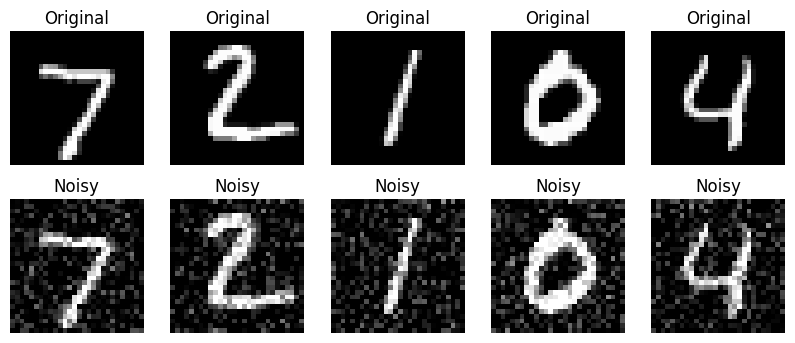

In [3]:
# Add random noise to the images
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# Clip the pixel values to be between 0 and 1
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

# Display some noisy and clean images
def plot_images(original, noisy, num_images=5):
    plt.figure(figsize=(10, 4))
    for i in range(num_images):
        # Original Image
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(tf.squeeze(original[i]), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Noisy Image
        ax = plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(tf.squeeze(noisy[i]), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")
    plt.show()

plot_images(x_test, x_test_noisy)


## 3. Autoencoder Model Architecture

We'll define a convolutional autoencoder model using Keras. This model will consist of an encoder that learns to compress the noisy input image into a lower-dimensional latent space, and a decoder that learns to reconstruct a clean image from this latent representation.

In [4]:
class DenoisingAutoencoder(tf.keras.Model):
  def __init__(self):
    super(DenoisingAutoencoder, self).__init__()
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
      tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
      tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)
    ])

    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, activation='relu', padding='same'),
      tf.keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
      tf.keras.layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = DenoisingAutoencoder()
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.encoder.summary()
autoencoder.decoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Autoencoder

Now, let's train our `DenoisingAutoencoder` model. We'll feed the noisy images (`x_train_noisy`) as input and the original clean images (`x_train`) as the target output.

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 263ms/step - loss: 0.1155 - val_loss: 0.1140
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 262ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 260ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 258ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 258ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 261ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 258ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 260ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.1120 - val_loss: 0.1140


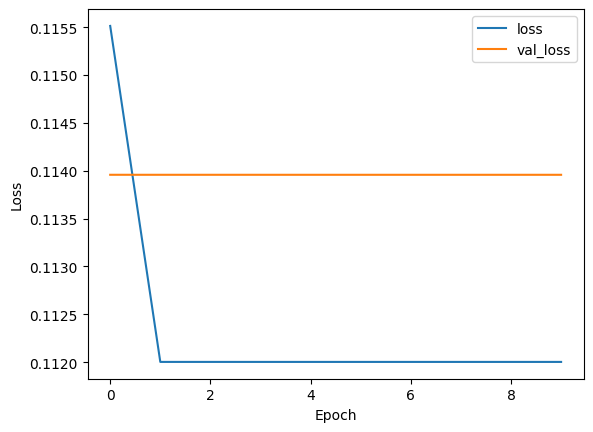

In [5]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 5. Evaluate and Visualize Denoising Results

After training, we can use our autoencoder to predict denoised images from the noisy test set and compare them with the original clean images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step


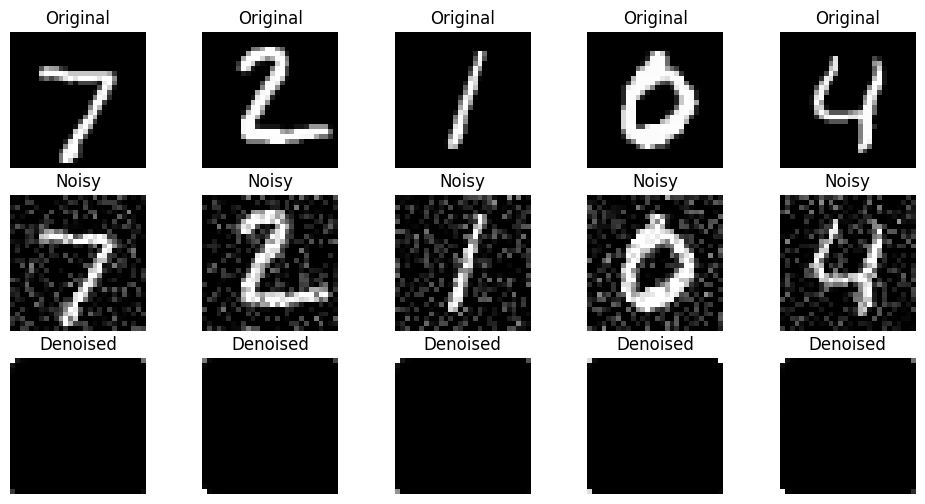

In [6]:
decoded_imgs = autoencoder.predict(x_test_noisy)

def plot_denoised_images(original, noisy, denoised, num_images=5):
    plt.figure(figsize=(12, 6))
    for i in range(num_images):
        # Original Image
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(tf.squeeze(original[i]), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Noisy Image
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(tf.squeeze(noisy[i]), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        # Denoised Image
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(tf.squeeze(denoised[i]), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")
    plt.show()

plot_denoised_images(x_test, x_test_noisy, decoded_imgs)